In [1]:
import cafe
import scanpy as sc

cafe.settings.backend = "python_function"
cafe.logger.setLevel("INFO")

[07/17/2025 04:48:55] INFO                                                                                                                                                                              
                                  _____     _ _ ______    _       ______            _                                                                                                                   
                                 / ____|   | | |  ____|  | |     |  ____|          | |                                                                                                                  
                                | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __                                                                                               
                                | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__|                                                                                          

数据

In [2]:
# 读取scvelo的pancreas数据
adata = sc.read_h5ad("/home/huang/PyCode/scRNA/data/Pancreas/endocrinogenesis_day15.h5ad")
fadata = cafe.data.FateAnnData.from_anndata(adata)
fadata.layers["expression"] = fadata.layers["spliced"]
fadata.layers["count"] = fadata.layers["spliced"]

basis = "umap"
cluster_key = "clusters"

fadata.obs.index = [f"cell_{i:03d}" for i in range(fadata.shape[0])]
fadata

AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'cfe'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'count'

In [3]:
import pandas as pd

# 手动添加参考里程碑
milestone_network = pd.DataFrame(
    data=[
        ["Ductal", "Ngn3 low EP"],
        ["Ngn3 low EP", "Ngn3 high EP"],
        ["Ngn3 high EP", "Pre-endocrine"],
        ["Pre-endocrine", "Alpha"],
        ["Pre-endocrine", "Beta"],
        ["Pre-endocrine", "Delta"],
        ["Pre-endocrine", "Epsilon"],
    ],
    columns=["from", "to"],
)

fadata.add_trajectory_mannually(milestone_network)

In [ ]:
cluster_key = "milestone_color"
fadata.group_onto_nearest_milestones(cluster_key=cluster_key)  # new cluster color

cluster_key_list = ["milestone"]
# cluster_key_list = ["milestone", cluster_key]
cafe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list, curve=True)
cafe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list, curve=False)
cafe.plot.plot_wrapper(fadata)
fadata

In [ ]:
prior_information = {}
fadata.add_prior_information(**prior_information)  # add prior information to fadata
parameters = {}


method_name_list = ["scvelo"]

for method_name in method_name_list:
    method = cafe.method.FateMethod(method_name=method_name)
    method.infer_trajectory(fadata)

[07/17/2025 04:24:42] INFO     Loaded function: <function cf_scvelo at 0x74094f686710> from /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/cf_scvelo.py                 
                      INFO     method_backend: <cafe.method.fate_function_backend.FunctionBackend object at 0x740ac823fa60>                                                                              
Filtered out 20801 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.
Logarithmized X.
computing neighbors
    finished (0:00:02) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (usi

  0%|          | 0/3696 [00:00<?, ?cells/s]

    finished (0:00:03) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
or is corrupted (e.g. due to subsetting). Consider recomputing with `pp.neighbors`.
computing terminal states
    identified 2 regions of root cells and 1 region of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
running PAGA using priors: ['velocity_pseudotime']
    finished (0:00:00) --> added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns)
    'paga/transitions_confidence', velocity transitions (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


额外绘制wrapper

KeyError: 'milestone_color_dict'

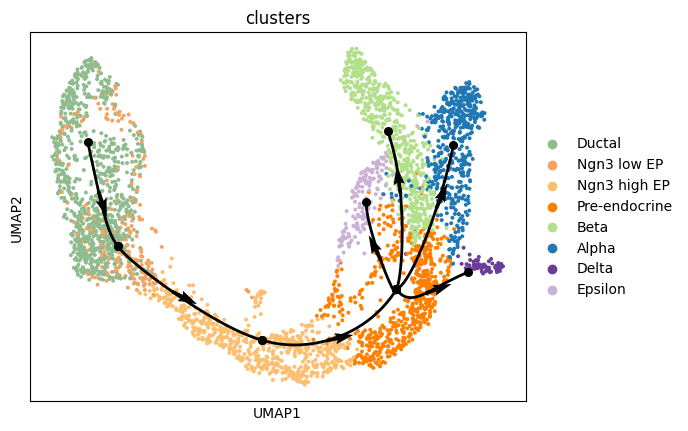

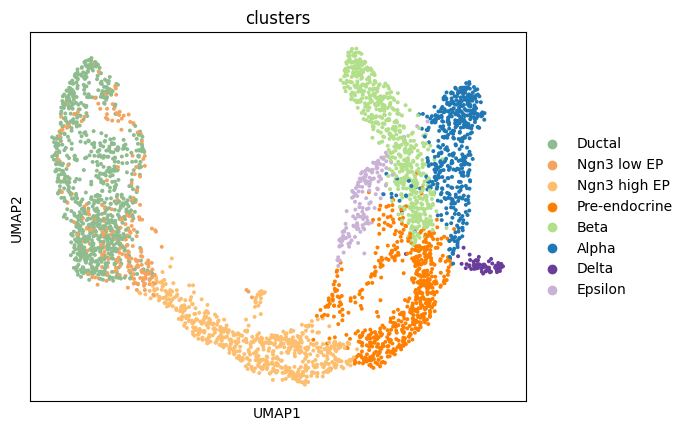

In [ ]:
cluster_key = "clusters"

cafe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key)
cafe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key, curve=False)
cafe.plot.plot_graph(fadata, color=cluster_key)
cafe.plot.plot_wrapper(fadata)